# Settings

In [1]:
library(dplyr)
library(preprocessCore)
library(ggplot2)
library(reshape2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘preprocessCore’ was built under R version 4.4.2”


In [2]:
# input files
rowdata <- readRDS("../format_expression_data/rowdata_mouse.rds")
coldata <- readRDS("../format_expression_data/Cardoso-Moreira/coldata_mouse.rds")
exprmat <- readRDS("../format_expression_data/Cardoso-Moreira/exprmat_mouse.rds")
layout <- readRDS("../format_expression_data/Cardoso-Moreira/layout_mouse.rds")
out.file.prefix <- "c-m_mouse_"

# - FUSIL file
fusil_file <- "../input_data/FUSIL/fusil_all_260724.txt"

In [3]:
# Filter unmeasured genes 
print(paste0("N genes exprmat: ", nrow(exprmat)))
print(paste0("N genes rowdata: ", nrow(rowdata)))

any.na <- function(vals){
    return(any(is.na(vals)))}
temp.keep <- which(!apply(exprmat, MARGIN=1, FUN=any.na))
exprmat.filt <- exprmat[temp.keep,]
rowdata.filt <- rowdata[temp.keep,]
print(paste("N genes after filt NAs exprmat: ", nrow(exprmat.filt), sep=""))
print(paste("N genes after filt NAs rowdata: ", nrow(rowdata.filt), sep=""))

all.zero <- function(vals){
    return(all(vals==0))}
temp.keep <- which(!apply(exprmat.filt, MARGIN=1, FUN=all.zero))
exprmat.filt <- exprmat.filt[temp.keep,]
rowdata.filt <- rowdata.filt[temp.keep,]
print(paste("N genes after filt 0s exprmat: ", nrow(exprmat.filt), sep=""))
print(paste("N genes after filt 0s rowsata: ", nrow(rowdata.filt), sep=""))

[1] "N genes exprmat: 42319"
[1] "N genes rowdata: 42319"
[1] "N genes after filt NAs exprmat: 26228"
[1] "N genes after filt NAs rowdata: 26228"
[1] "N genes after filt 0s exprmat: 24126"
[1] "N genes after filt 0s rowsata: 24126"


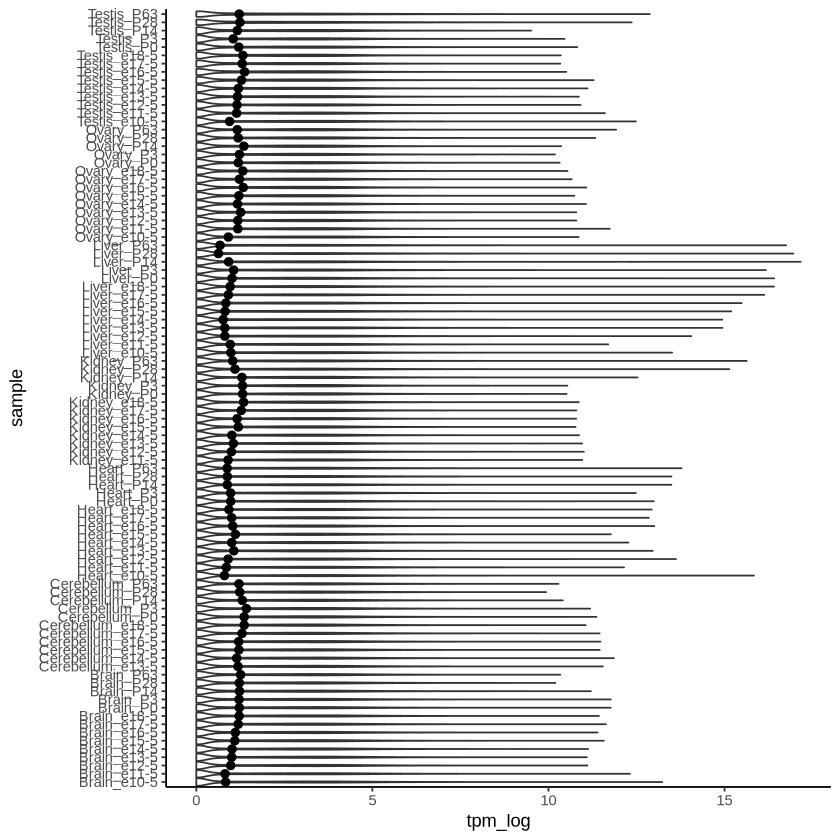

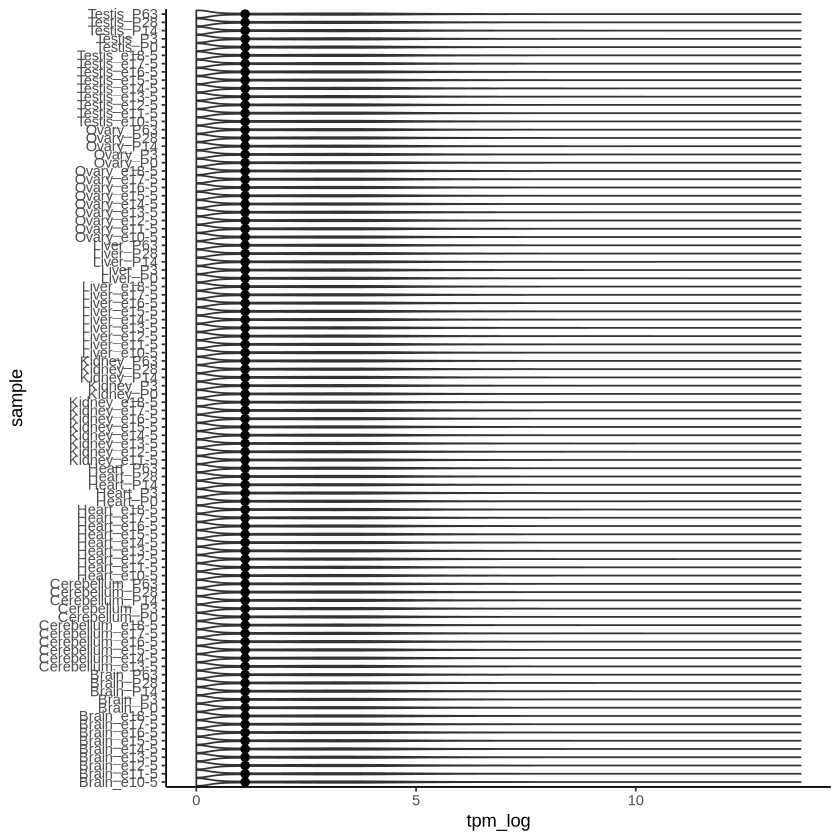

In [4]:
# quantile normalize expression distributions
exprmat.filt.norm <- normalize.quantiles(exprmat.filt)
rownames(exprmat.filt.norm) <- rownames(exprmat.filt)
colnames(exprmat.filt.norm) <- colnames(exprmat.filt)

p <- exprmat.filt %>% 
    melt() %>%
    'colnames<-'(c("hgnc_id", "sample", "tpm")) %>%
    mutate(tpm_log=log2(tpm+1)) %>%
    ggplot(aes(x=tpm_log, y=sample)) + geom_violin() + 
    stat_summary(fun=median, geom="point", size=2) + theme_classic()

p.norm <- exprmat.filt.norm %>% 
    melt() %>%
    'colnames<-'(c("hgnc_id", "sample", "tpm")) %>%
    mutate(tpm_log=log2(tpm+1)) %>%
    ggplot(aes(x=tpm_log, y=sample)) + geom_violin() + 
    stat_summary(fun=median, geom="point", size=2) + theme_classic()

p
p.norm

In [5]:
# Find max tissue

#function to find maximum expression column of return multiple if more than one
max.col <- function(vals){
    temp <- which(vals==max(vals))
    if(length(temp)==1){
        return(temp)
    } else if(length(temp)>1){
        return("multiple")
    } else{
        return(NA)}
}

max.col.tab <- data.frame("max_col_raw"=apply(exprmat.filt, 1, max.col)) %>%
    mutate("max_col_norm"=apply(exprmat.filt.norm, 1, max.col)) %>% 
    tibble::rownames_to_column(var="mgi_id")
max.col.tab$max_sample_raw <- coldata$label[max.col.tab$max_col_raw %>% as.numeric()]
max.col.tab$max_sample_norm <- coldata$label[max.col.tab$max_col_norm %>% as.numeric()]
max.col.tab$max_tissue_raw <- coldata$tissue[max.col.tab$max_col_raw %>% as.numeric()]
max.col.tab$max_tissue_norm <- coldata$tissue[max.col.tab$max_col_norm %>% as.numeric()]
max.col.tab$max_stage_raw <- coldata$stage[max.col.tab$max_col_raw %>% as.numeric()]
max.col.tab$max_stage_norm <- coldata$stage[max.col.tab$max_col_norm %>% as.numeric()]

max.col.tab[which(max.col.tab$max_col_raw=="multiple"), c("max_sample_raw", "max_tissue_raw", "max_stage_raw")] <- rep("multiple", 3)
max.col.tab[which(max.col.tab$max_col_norm=="multiple"), c("max_sample_norm", "max_tissue_norm", "max_stage_norm")] <- rep("multiple", 3)

nrow(max.col.tab)
head(max.col.tab)

Warning message in max.col.tab$max_col_norm %>% as.numeric():
“NAs introduced by coercion”
Warning message in max.col.tab$max_col_norm %>% as.numeric():
“NAs introduced by coercion”
Warning message in max.col.tab$max_col_norm %>% as.numeric():
“NAs introduced by coercion”


[1] 24126

,mgi_id,max_col_raw,max_col_norm,max_sample_raw,max_sample_norm,max_tissue_raw,max_tissue_norm,max_stage_raw,max_stage_norm
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,MGI:1914088,94,94,Testis_P63,Testis_P63,Testis,Testis,P63,P63
2,MGI:1915609,15,57,Cerebellum_e13-5,Liver_e14-5,Cerebellum,Liver,e13-5,e14-5
3,MGI:1915614,65,65,Liver_P28,Liver_P28,Liver,Liver,P28,P28
4,MGI:1917595,38,38,Heart_P28,Heart_P28,Heart,Heart,P28,P28
5,MGI:1915636,93,93,Testis_P28,Testis_P28,Testis,Testis,P28,P28
6,MGI:1923511,64,64,Liver_P14,Liver_P14,Liver,Liver,P14,P14


# Add to FUSIL table

In [6]:
fusil <- read.delim(fusil_file, as.is=T, sep = "\t", header = T)
fusil[fusil == '-'] <- NA

# view summary
print(paste("## FUSIL calls loaded: ", nrow(fusil)))

[1] "## FUSIL calls loaded:  8037"


In [7]:
fusil_additions <- left_join(fusil, max.col.tab, by="mgi_id")
nrow(fusil_additions)
head(fusil_additions)

[1] 8037

,mgi_id,viability,wol,mp_term_id_homozygote,mp_term_id_heterozygote,mp_term_id_hemizygote,mp_term_name_homozygote,mp_term_name_heterozygote,mp_term_name_hemizygote,allele_symbol_homozygote,⋯,fusil_all,fusil,max_col_raw,max_col_norm,max_sample_raw,max_sample_norm,max_tissue_raw,max_tissue_norm,max_stage_raw,max_stage_norm
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,MGI:101759,viable,NA,MP:0001399|MP:0001406|MP:0005565|MP:0010088|MP:0005419,NA,NA,hyperactivity|abnormal gait|increased blood urea nitrogen level|decreased circulating fructosamine level|decreased circulating serum albumin level,NA,NA,Syt4<em2(IMPC)H>,⋯,VP,VP,9,9,Brain_e18-5,Brain_e18-5,Brain,Brain,e18-5,e18-5
2,MGI:101760,lethal,early lethal,MP:0013292|MP:0011100,MP:0005333|MP:0010506|MP:0010053|MP:0002941,NA,"embryonic lethality prior to organogenesis|preweaning lethality, complete penetrance",decreased heart rate|prolonged RR interval|decreased grip strength|increased circulating alanine transaminase level,NA,Sfswap<em1(IMPC)J>,⋯,CL,CL,10,8,Brain_P0,Brain_e17-5,Brain,Brain,P0,e17-5
3,MGI:101766,lethal,late lethal,MP:0011100|MP:0003984|MP:0001785|MP:0000111|MP:0000428|MP:0001711,MP:0000691|MP:0002135|MP:0000266|MP:0000689|MP:0001289|MP:0002060|MP:0000220|MP:0000274|MP:0006203|MP:0005013|MP:0003068|MP:0001711|MP:0000218,NA,"preweaning lethality, complete penetrance|embryonic growth retardation|edema|cleft palate|abnormal craniofacial morphology|abnormal placenta morphology",enlarged spleen|abnormal kidney morphology|abnormal heart morphology|abnormal spleen morphology|persistence of hyaloid vascular system|abnormal skin morphology|increased monocyte cell number|enlarged heart|eye hemorrhage|increased lymphocyte cell number|enlarged kidney|abnormal placenta morphology|increased leukocyte cell number,NA,Ryk<em1(IMPC)Mbp>,⋯,DL,DL,40,43,Kidney_e11-5,Kidney_e14-5,Kidney,Kidney,e11-5,e14-5
4,MGI:101769,lethal,early lethal,MP:0013292|MP:0011100,MP:0003984|MP:0002092|MP:0000702|MP:0002590|MP:0001297|MP:0002339|MP:0010052|MP:0000692|MP:0002188|MP:0001293|MP:0000266,NA,"embryonic lethality prior to organogenesis|preweaning lethality, complete penetrance",embryonic growth retardation|abnormal eye morphology|enlarged lymph nodes|increased mean corpuscular volume|microphthalmia|abnormal lymph node morphology|increased grip strength|small spleen|small heart|anophthalmia|abnormal heart morphology,NA,Mcl1<em1(IMPC)Mbp>,⋯,CL,CL,39,39,Heart_P63,Heart_P63,Heart,Heart,P63,P63
5,MGI:101770,viable,NA,MP:0004906|MP:0002092|MP:0001102|MP:0001488,NA,NA,enlarged uterus|abnormal eye morphology|small superior vagus ganglion|increased startle reflex,NA,NA,Bfsp1<tm1b(EUCOMM)Wtsi>,⋯,VP,VP,77,77,Ovary_P3,Ovary_P3,Ovary,Ovary,P3,P3
6,MGI:101774,viable,NA,NA,NA,NA,NA,NA,NA,NA,⋯,VnP_insufficient_procedures,NA,62,62,Liver_P0,Liver_P0,Liver,Liver,P0,P0


# save output

In [8]:
saveRDS(fusil_additions, file=paste0(out.file.prefix, "max_tissue.rds"))
write.table(fusil_additions, quote=F, row.names=F, sep="\t", file=paste0(out.file.prefix, "max_tissue.tsv"))